In [35]:
# -*- coding: utf-8 -*-
"""
Created on Wed Oct 25 18:16:33 2023

@author: sowmya
"""

import cv2
import numpy as np
from keras.models import load_model
import tensorflow as tf
import keras.backend as K
from PIL import Image
from tensorflow.keras.losses import sparse_categorical_crossentropy


def calc_cm_vals(y_true, y_pred, class_index=None):
    pred = tf.argmax(y_pred, axis=1)
    true = tf.reshape(y_true, (-1,))

    tp = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(true, class_index),
                                              tf.equal(pred, class_index)),
                                               tf.float32))
    fp = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(true, class_index),
                                              tf.equal(pred, class_index)),
                                               tf.float32))
    fn = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(true, class_index),
                                             tf.not_equal(pred, class_index)),
                                              tf.float32))
    return tp, fp, fn


def precision_1(y_true, y_pred, class_index=1):
    tp, fp, fn = calc_cm_vals(y_true, y_pred, class_index)
    return tp / (tp + fp + K.epsilon())

def recall_1(y_true, y_pred, class_index=1):
    tp, fp, fn = calc_cm_vals(y_true, y_pred, class_index)
    return tp / (tp + fn + K.epsilon())

def f1_score_1(y_true, y_pred, class_index=1):
    precision = precision_1(y_true, y_pred, class_index)
    recall = recall_1(y_true, y_pred, class_index)
    f1_score = 2 * (precision * recall) / (precision + recall + K.epsilon())
    return f1_score

def f1_score_1_loss(y_true, y_pred):
    f1_score = f1_score_1(y_true, y_pred)
    ce_loss = sparse_categorical_crossentropy(y_true, y_pred,
                                              from_logits=False, axis=-1)
    alpha = 0.00001
    combined_loss = alpha * ce_loss + (1 - alpha) * (1-f1_score)
    return combined_loss




def preprocess_img(image, target_size):
    if image is not None:
        height, width, channels = image.shape
        if width<height :
            image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    preprocessed_image = cv2.resize(image, target_size)
    reshaped_image = preprocessed_image.reshape(1, *preprocessed_image.shape)

    image = reshaped_image.astype(np.float32)
    image = image / 255.0
    return image

def predict_image(preprocessed_img, model, label_map):
    prediction = model.predict(preprocessed_img)
    prediction = np.array([np.argmax(pred) for pred in prediction])
    reverse_label_map = {idx: img_type for img_type, idx in label_map.items()}
    predicted_class = reverse_label_map[prediction[0]]
    return predicted_class





def main(img_path = ''):
    model_path = "/content/drive/MyDrive/Sowmya /models/prawns single-group classification/best.h5"
    label_map = {'Group': 0, 'Single': 1}
    target_size = (224, 224)

    custom_metrics = {'f1_score_1_loss':f1_score_1_loss}

    model = load_model(model_path, custom_objects=custom_metrics)
    img = Image.open(img_path)
    display(img.resize((200, 200)))
    img = np.array(img)
    preprocessed_img = preprocess_img(img, target_size)
    predicted_class = predict_image(preprocessed_img, model, label_map)
    # print(predicted_class)
    return predicted_class

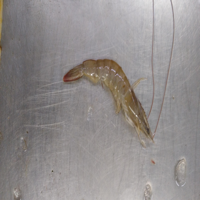

1/1 [==============================] - 2s 2s/step


'Single'

In [36]:
main("/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2023-12-03/White prawns/Bad/20231203100159048_white prawns_bad.jpeg")

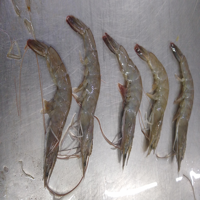

1/1 [==============================] - 1s 1s/step


'Group'

In [37]:
main("/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data/2023-12-03/White prawns/Bad/20231203101659697_white prawns_bad.jpeg")